# Часть 1. Эталон GARCH на реальных данных

S&P 500, дневные log-returns. Train: 2010–2019, Test: 2020–2024 (стресс).
Здесь обучаем GARCH(1,1)-t только на реальных данных и фиксируем эталонные метрики для последующего сравнения с GAN-вариантами в части 2.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from src import data as dm
from src import garch_eval as ge
from src import stylized as sf

SEED = 42
np.random.seed(SEED)
SCALE = ge.SCALE  # GARCH работает в %, returns умножаем на 100

## Данные

In [2]:
prices, returns = dm.load_or_download()
train, test = dm.train_test_split(returns)

print(f"train: {len(train)}  {train.index.min().date()} -> {train.index.max().date()}")
print(f"test : {len(test)}  {test.index.min().date()} -> {test.index.max().date()}")
print(f"\nreturns в %, описательные статистики:")
print((returns * 100).describe()[["mean", "std", "min", "max"]].round(3))

train: 2515  2010-01-05 -> 2019-12-31
test : 1258  2020-01-02 -> 2024-12-31

returns в %, описательные статистики:
mean     0.045
std      1.091
min    -12.765
max      9.089
Name: log_return, dtype: float64


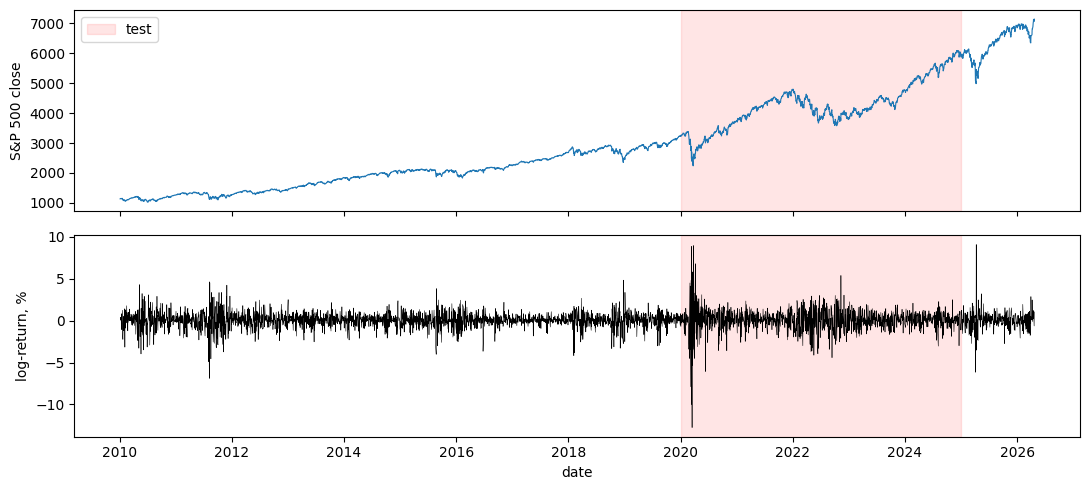

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(prices.index, prices["close"], lw=0.8)
ax[0].axvspan(test.index.min(), test.index.max(), alpha=0.1, color="red", label="test")
ax[0].set_ylabel("S&P 500 close"); ax[0].legend(loc="upper left")

ax[1].plot(returns.index, returns * 100, lw=0.4, color="black")
ax[1].axvspan(test.index.min(), test.index.max(), alpha=0.1, color="red")
ax[1].set_ylabel("log-return, %"); ax[1].set_xlabel("date")
plt.tight_layout(); plt.show()

## Стилизованные факты на real train

Что важно для GARCH: тяжёлые хвосты (kurtosis_excess > 0), кластеры волатильности (ACF |r| > 0 на нескольких лагах), желательно — левая асимметрия.

In [4]:
sf_real = sf.stylized_facts(train.values * SCALE, name="real_train")
keys = ["std", "skew", "kurtosis_excess", "min", "max",
        "acf1_abs_returns", "acf5_abs_returns", "acf10_abs_returns"]
print(pd.Series({k: round(sf_real[k], 3) for k in keys}, name="real_train"))
# вывод: kurtosis_excess > 0, skew < 0, ACF |r| > 0.2 на 10 лагах — всё, что нужно для GARCH.

std                  0.932
skew                -0.497
kurtosis_excess      4.597
min                 -6.896
max                  4.840
acf1_abs_returns     0.214
acf5_abs_returns     0.201
acf10_abs_returns    0.200
Name: real_train, dtype: float64


## GARCH(1,1)-t на real train

Нормальные диапазоны для дневных доходностей индексов:
ω ∈ [0.01, 0.10], α ∈ [0.05, 0.25], β ∈ [0.70, 0.92], α+β ∈ [0.93, 0.99], ν ∈ [4, 10].

In [5]:
params_real, _ = ge.fit_garch_const_mean(train, dist="t")
p = params_real.to_dict()
p["alpha+beta"] = p["alpha"] + p["beta"]
print(pd.Series({k: round(v, 4) for k, v in p.items() if isinstance(v, (int, float))}, name="B1"))
# omega, alpha, beta, alpha+beta, nu — всё в нормальных диапазонах -> здоровый эталон.

mu            0.0868
omega         0.0253
alpha         0.1759
beta          0.8126
nu            4.8739
alpha+beta    0.9884
Name: B1, dtype: float64


### Walk-forward на test (фиксированные параметры)

GARCH-параметры заморожены, σ̂_t рекурсивно обновляется по формуле σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}.
Метрики:
- RMSE/MAE по |r| — общая точность прогноза амплитуды
- QLIKE — robust loss для волатильности
- MZ_b ≈ 1 — калибровка
- VaR rate — доля дней-нарушений (норма ≈ ожидаемое значение alpha)

In [6]:
df_b1 = ge.walk_forward_fixed(params_real, history=train, test=test)
m_b1 = ge.evaluate_forecast(df_b1, params_real)

show = ["RMSE_abs_r", "QLIKE", "MZ_b", "MZ_R2",
        "VaR5_rate", "VaR5_kupiec_p", "VaR1_rate", "VaR1_kupiec_p"]
print(pd.Series({k: round(m_b1[k], 4) for k in show}, name="B1"))
# VaR5_rate ~0.08 (норма 0.05) — модель недооценивает риск на стресс-периоде 2020+.
# VaR1_rate ~0.016 — на границе нормы.

RMSE_abs_r       0.8867
QLIKE            1.0898
MZ_b             0.9002
MZ_R2            0.3042
VaR5_rate        0.0787
VaR5_kupiec_p    0.0000
VaR1_rate        0.0159
VaR1_kupiec_p    0.0528
Name: B1, dtype: float64


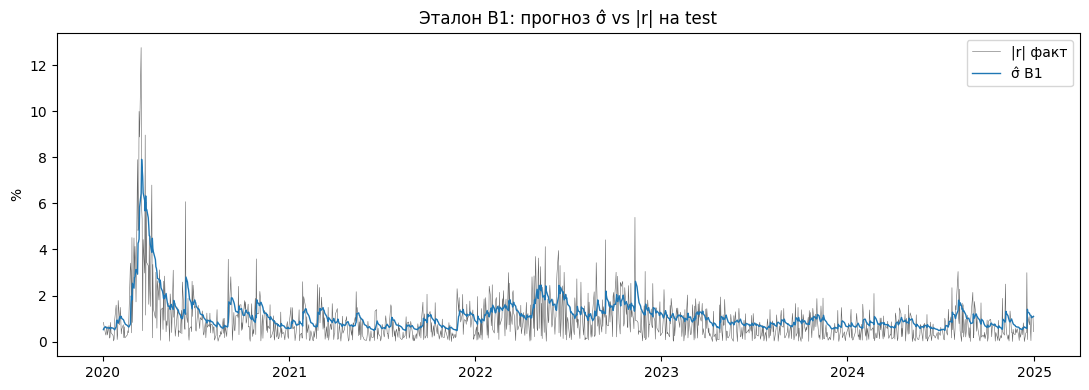

In [7]:
df_var = ge.var_forecast(df_b1, params_real, alphas=(0.05, 0.01))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_var.index, np.abs(df_var["r_pct"]), lw=0.4, color="black", alpha=0.6, label="|r| факт")
ax.plot(df_var.index, df_var["sigma_pct"], lw=1.0, color="C0", label="σ̂ B1")
ax.set_ylabel("%"); ax.set_title("Эталон B1: прогноз σ̂ vs |r| на test")
ax.legend(); plt.tight_layout(); plt.show()

In [8]:
# кладём в общий dict, чтобы во второй части использовать как точку отсчёта
import json
ART = ROOT / "artifacts"; ART.mkdir(exist_ok=True)
(ART / "garch_params_real.json").write_text(json.dumps(params_real.to_dict(), indent=2), encoding="utf-8")
df_b1.to_csv(ART / "forecasts_B1.csv")
pd.Series(m_b1).to_json(ART / "metrics_B1.json", indent=2)
print("saved: artifacts/garch_params_real.json, forecasts_B1.csv, metrics_B1.json")

saved: artifacts/garch_params_real.json, forecasts_B1.csv, metrics_B1.json


**Итог по эталону.** Параметры здоровые. RMSE ≈ 0.89, MZ_b ≈ 0.9, VaR(5%) ≈ 8% (выше нормы — стресс 2020+). Дальше всё сравниваем с этими цифрами.